In this script you find the process to apply multiple_Linear_Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import sklearn.model_selection as model_selection
import statsmodels.api as sm

Upload the csv file

In [6]:
df=pd.read_csv('Multiple_logistic_Regression.csv',sep=',')
print(df.head())

   Study_Hours  Attendance_Percent  ...  Sleep_Hours  Pass
0         9.87                70.7  ...          7.1     1
1        11.63                76.7  ...          6.2     1
2         7.49                89.9  ...          7.1     1
3         1.17                76.8  ...          5.1     0
4         3.61                82.0  ...          6.3     1

[5 rows x 6 columns]


Dividing the dataset in to Independed  vs  depended  variable

In [10]:
X=df[['Study_Hours','Attendance_Percent','Assignments_Completed','Previous_Score','Sleep_Hours']]
Y=df['Pass']

Print the  head of the variabales

In [11]:
print(X.head())
print(Y.head())

   Study_Hours  Attendance_Percent  ...  Previous_Score  Sleep_Hours
0         9.87                70.7  ...            66.7          7.1
1        11.63                76.7  ...            64.4          6.2
2         7.49                89.9  ...            57.8          7.1
3         1.17                76.8  ...            60.4          5.1
4         3.61                82.0  ...            71.2          6.3

[5 rows x 5 columns]
0    1
1    1
2    1
3    0
4    1
Name: Pass, dtype: int64


Build logistic_Regression

In [ ]:
logistic_model=sm.Logit(Y,X).fit()

Optimization terminated successfully.
         Current function value: 0.166200
         Iterations 8


Summeries the Logistic model

In [15]:
print(logistic_model.summary())

                           Logit Regression Results                           
Dep. Variable:                   Pass   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      995
Method:                           MLE   Df Model:                            4
Date:                Mon, 17 Aug 2026   Pseudo R-squ.:                  0.1750
Time:                        17:10:38   Log-Likelihood:                -166.20
converged:                       True   LL-Null:                       -201.45
Covariance Type:            nonrobust   LLR p-value:                 1.782e-14
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Study_Hours               0.3618      0.065      5.555      0.000       0.234       0.489
Attendance_Percent       -0.0223      0.012     -1.931      0.054      -0.045       0.000
Assignme

Gtting a Constant  in the model

In [19]:
X = sm.add_constant(X)
logistic_model = sm.Logit(Y, X).fit()
print(logistic_model.summary())

Optimization terminated successfully.
         Current function value: 0.146480
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                   Pass   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      994
Method:                           MLE   Df Model:                            5
Date:                Mon, 17 Aug 2026   Pseudo R-squ.:                  0.2729
Time:                        17:16:32   Log-Likelihood:                -146.48
converged:                       True   LL-Null:                       -201.45
Covariance Type:            nonrobust   LLR p-value:                 4.222e-22
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Study_Hours               0.4496      0.075      6.018      0.000       0.303       0.

# Results of the Multiple Logistic Regression Model With an Intercept

The second model is a **Multiple Logistic Regression model with an intercept**, estimated using the five explanatory variables:

* `Study_Hours`
* `Attendance_Percent`
* `Assignments_Completed`
* `Previous_Score`
* `Sleep_Hours`


---
## 2. Regression Results

| Variable                  |  Coefficient | Std. Error | z-statistic | p-value |
| ------------------------- | -----------: | ---------: | ----------: | ------: |
| **const**                 | **-12.6900** |      2.158 |      -5.881 | < 0.001 |
| **Study_Hours**           |   **0.4496** |      0.075 |       6.018 | < 0.001 |
| **Attendance_Percent**    |   **0.0451** |      0.016 |       2.806 |   0.005 |
| **Assignments_Completed** |   **0.4870** |      0.104 |       4.703 | < 0.001 |
| **Previous_Score**        |   **0.0382** |      0.013 |       2.996 |   0.003 |
| **Sleep_Hours**           |   **0.6066** |      0.141 |       4.315 | < 0.001 |

---
## 3. Model Statistics
| Statistic      |                Result |
| -------------- | --------------------: |
| Observations   |                 1,000 |
| Log-Likelihood |               -146.48 |
| Pseudo (R^2)   |                0.2729 |
| LLR p-value    | (4.222\times10^{-22}) |
| Iterations     |                     9 |
| Convergence    |                   Yes |

---
## 4. Interpretation
All five explanatory variables have **positive coefficients**. This means that, holding the other variables constant, an increase in each variable is associated with an increase in the **log-odds of passing**.

* **Study_Hours (0.4496):** an additional hour of study is associated with higher odds of passing.
* **Attendance_Percent (0.0451):** higher attendance is associated with higher odds of passing.
* **Assignments_Completed (0.4870):** completing more assignments is associated with higher odds of passing.
* **Previous_Score (0.0382):** a higher previous score is associated with higher odds of passing.
* **Sleep_Hours (0.6066):** an additional hour of sleep is associated with higher odds of passing.

Importantly, **all five variables are statistically significant at the 5% level**, since all their (p)-values are below 0.05.
The intercept is:
                         -12.6900

and is also statistically significant ((p<0.001)). It represents the estimated baseline log-odds of passing when all explanatory variables are equal to zero.

## Overall conclusion
The model is **statistically significant overall**, as indicated by the extremely small LLR (p)-value:
                               P=4.222*〖10〗^(-22)

The Pseudo-(R^2) of **0.2729** indicates that the model provides a meaningful improvement over the null model. Most importantly, the inclusion of the intercept substantially changes the estimated coefficients compared with the previous no-intercept specification, demonstrating that **the presence or absence of a constant is a genuine model-specification choice, not merely a coding detail**.


Y_predict

In [24]:
Y_pred=Y_prob = logistic_model.predict(X)
Y_pred = (Y_prob >= 0.5).astype(int)


In [25]:
print(pd.DataFrame({
    'Y_actual': Y,
    'Y_probability': Y_prob,
    'Y_pred': Y_pred
}))

     Y_actual  Y_probability  Y_pred
0           1       0.998719       1
1           1       0.998935       1
2           1       0.996241       1
3           0       0.563229       1
4           1       0.907829       1
..        ...            ...     ...
995         1       0.802445       1
996         1       0.994616       1
997         1       0.987154       1
998         1       0.997425       1
999         1       0.959825       1

[1000 rows x 3 columns]


Calculate: Accuracy/precission/recal:
Accuracy=[TP+TN]/[TP+TN+FP+FN]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
accuracy = accuracy_score(Y, Y_pred)                 #######################   Accuracy= [TP+TN/TP+TN+FP+FN]
precision = precision_score(Y, Y_pred)               ######################   Precission= [TP/TP+FP]
recall = recall_score(Y, Y_pred)                     ######################   recal= [TP/TP+FN]

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.95
Precision: 0.9526686807653575
Recall: 0.9968387776606955


Roc Curve plot

AUC: 0.8771048988615467


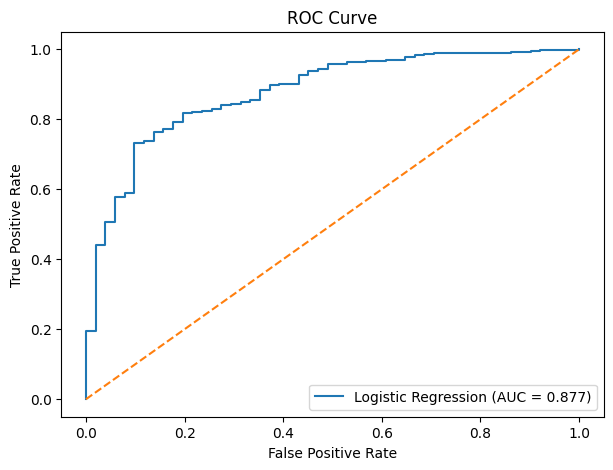

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate predicted probabilities
Y_prob = logistic_model.predict(X)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(Y, Y_prob)

# Calculate AUC
auc = roc_auc_score(Y, Y_prob)

print("AUC:", auc)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Interpretation of the ROC Curve

The ROC curve evaluates the ability of the **multiple logistic regression model** to distinguish between the two possible outcomes:

* **Pass = 1**
* **Fail = 0**
The horizontal axis represents the **False Positive Rate (FPR)**, while the vertical axis represents the **True Positive Rate (TPR)**, also known as **Recall/Sensitivity**.

## 1. Shape of the ROC Curve
The blue ROC curve lies substantially **above the diagonal orange line** across most of the graph. This indicates that the logistic regression model performs considerably better than random classification.

The orange dashed line represents a model with **no discriminatory ability**, for which:
                    AUC=0.5

Therefore, the position of the blue curve above this reference line provides visual evidence that the model can distinguish between students who pass and those who fail.

---
## 2. AUC = 0.877
The most important result in the graph is:
                AUC=0.877

The **Area Under the ROC Curve (AUC)** summarizes the model's ability to discriminate between the two classes across different classification thresholds.

An AUC of **0.877** indicates **good discriminatory performance**.

In practical terms, the model has a strong ability to distinguish students who are likely to **Pass** from those who are likely to **Fail**.

Another useful interpretation is that an AUC of 0.877 means that, when randomly selecting one student from each class, the model will assign a higher predicted probability of passing to the student who actually passes than to the student who fails in approximately **87.7% of comparable pairs**.

---
## 3. Interpretation of the True Positive Rate
The vertical axis shows the **True Positive Rate (TPR)**:

                                   TPR=\frac{TP}{TP+FN}

A higher TPR means that the model correctly identifies a larger proportion of students who actually pass.

For example, from the graph, the model reaches a TPR of approximately **0.80** while the FPR is around **0.20**. This means that at an appropriate threshold, the model can correctly identify roughly 80% of passing students while incorrectly classifying approximately 20% of failing students as passing.

---
## 4. Interpretation of the False Positive Rate

The horizontal axis represents the **False Positive Rate**:

                              FPR=\frac{FP}{FP+TN}

A low FPR is desirable because it means that fewer students who actually fail are incorrectly classified as passing.

The ROC curve shows that the model can achieve relatively high true-positive rates without requiring an equally high false-positive rate.

---
## 5. The Diagonal Reference Line

The orange dashed line represents random classification:
                                    TPR=FPR

A classifier following this line would have:
                                   AUC=0.5
Therefore:
                                  0.877 > 0.5
which confirms that the logistic regression model performs substantially better than random guessing.
---
## 6. Overall Assessment

The ROC curve provides evidence that the logistic regression model has **good discriminatory power**. The curve remains considerably above the random-classification line, and the AUC of **0.877** indicates that the model is effective at distinguishing between `Pass` and `Fail`.

However, the ROC curve does **not** by itself determine the optimal classification threshold. The model may perform differently in terms of Accuracy, Precision, and Recall depending on the selected threshold.

Therefore, the ROC/AUC result should be considered together with the other classification measures.

### Formal conclusion

> **The ROC analysis indicates that the multiple logistic regression model demonstrates good discriminatory ability, with an AUC of 0.877. The ROC curve lies substantially above the random-classification reference line, indicating that the model can effectively distinguish between students who pass and those who fail across a range of classification thresholds. Nevertheless, AUC measures overall discrimination and does not by itself determine the optimal classification threshold; therefore, it should be interpreted alongside Accuracy, Precision, Recall, and other evaluation measures.**
